# Ablation Study — Feature Contribution to Risk Classification
## London Urban Safety Classification

**Purpose:** Quantify how much each of the 6 spatial features contributes to classification performance. We train Logistic Regression and Random Forest on all 6 features (the *baseline*), then retrain with one feature removed at a time and measure the accuracy drop.

A large drop when a feature is removed → that feature carries significant information.  
A small or zero drop → the remaining features can compensate, or the feature is redundant.

**Note:** The target labels are K-Means pseudo-labels from `04_KMeans.ipynb`, so accuracy measures how well the model reproduces the cluster boundary — not ground-truth crime outcomes. Nonetheless, the relative drops are a valid signal of feature importance within this pipeline.

In [2]:
import os
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

warnings.filterwarnings('ignore')
sns.set_style('darkgrid')
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42
RISK_ORDER   = ['low', 'medium', 'high']
RISK_COLORS  = {'low': '#2ecc71', 'medium': '#f39c12', 'high': '#e74c3c'}

## Step 1: Load Data

In [4]:
FEATURE_COLS = [
    'lighting_norm',
    'visibility_norm',
    'connectivity_norm',
    'enclosure_norm',
    'dominant_land_use_score_norm',
    'public_transport_proximity_m_norm'
]

FEATURE_LABELS = {
    'lighting_norm':                    'Lighting',
    'visibility_norm':                  'Visibility',
    'connectivity_norm':                'Connectivity',
    'enclosure_norm':                   'Enclosure',
    'dominant_land_use_score_norm':     'Land Use Score',
    'public_transport_proximity_m_norm':'Transport Proximity'
}
clean_name = lambda col: FEATURE_LABELS.get(col, col.replace('_norm', ''))

csv_path = r'C:\Users\maria\Documents\GitHub\MaCAD26-G01-DataEncoding\csv\segment_risk_classified.csv'
df = pd.read_csv(csv_path)

# Drop rows with missing features or labels
df = df.dropna(subset=FEATURE_COLS + ['risk_class']).reset_index(drop=True)
df['risk_class'] = pd.Categorical(df['risk_class'], categories=RISK_ORDER, ordered=True)

print(f'Loaded {len(df):,} segments')
print(f'Risk class distribution:')
print(df['risk_class'].value_counts().reindex(RISK_ORDER))

Loaded 35,978 segments
Risk class distribution:
risk_class
low       12166
medium    16518
high       7294
Name: count, dtype: int64


## Step 2: Establish Baseline (All 6 Features)

We replicate the exact setup from `05_ClassificationML.ipynb` to get the baseline accuracy for both models.

In [5]:
def train_and_evaluate(feature_subset, df, random_state=42):
    """Train LR and RF on `feature_subset`, return accuracy metrics dict."""
    X = df[feature_subset].values
    y = df['risk_class'].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state, stratify=y
    )

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

    # Logistic Regression
    lr = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=random_state)
    lr.fit(X_train_s, y_train)
    cv_lr = cross_val_score(lr, X_train_s, y_train, cv=cv, scoring='accuracy')

    # Random Forest
    rf = RandomForestClassifier(n_estimators=100, random_state=random_state, n_jobs=-1)
    rf.fit(X_train_s, y_train)
    cv_rf = cross_val_score(rf, X_train_s, y_train, cv=cv, scoring='accuracy')

    return {
        'lr_test':  accuracy_score(y_test, lr.predict(X_test_s)),
        'lr_cv':    cv_lr.mean(),
        'lr_cv_std':cv_lr.std(),
        'rf_test':  accuracy_score(y_test, rf.predict(X_test_s)),
        'rf_cv':    cv_rf.mean(),
        'rf_cv_std':cv_rf.std(),
    }

print('Training baseline (all 6 features)...')
baseline = train_and_evaluate(FEATURE_COLS, df)
print(f"  LR  — test: {baseline['lr_test']:.4f}  |  CV: {baseline['lr_cv']:.4f} ± {baseline['lr_cv_std']:.4f}")
print(f"  RF  — test: {baseline['rf_test']:.4f}  |  CV: {baseline['rf_cv']:.4f} ± {baseline['rf_cv_std']:.4f}")

Training baseline (all 6 features)...
  LR  — test: 0.9985  |  CV: 0.9976 ± 0.0006
  RF  — test: 0.9787  |  CV: 0.9694 ± 0.0029


## Step 3: Leave-One-Out Ablation

We retrain with each feature removed in turn and record the accuracy delta relative to the baseline.  
A **negative delta** means removing that feature hurt performance (the feature was useful).  
A **positive delta** means removing it had no effect or slightly helped (possible redundancy or noise).

In [6]:
rows = []

for dropped in FEATURE_COLS:
    subset = [f for f in FEATURE_COLS if f != dropped]
    label  = clean_name(dropped)
    print(f'  Dropping: {label}...')
    metrics = train_and_evaluate(subset, df)
    rows.append({
        'dropped_feature': label,
        'lr_test':         metrics['lr_test'],
        'lr_cv':           metrics['lr_cv'],
        'lr_cv_std':       metrics['lr_cv_std'],
        'rf_test':         metrics['rf_test'],
        'rf_cv':           metrics['rf_cv'],
        'rf_cv_std':       metrics['rf_cv_std'],
        'lr_test_delta':   metrics['lr_test'] - baseline['lr_test'],
        'lr_cv_delta':     metrics['lr_cv']   - baseline['lr_cv'],
        'rf_test_delta':   metrics['rf_test'] - baseline['rf_test'],
        'rf_cv_delta':     metrics['rf_cv']   - baseline['rf_cv'],
    })

ablation_df = pd.DataFrame(rows)
print('\nDone.')

  Dropping: Lighting...
  Dropping: Visibility...
  Dropping: Connectivity...
  Dropping: Enclosure...
  Dropping: Land Use Score...
  Dropping: Transport Proximity...

Done.


## Step 4: Results Table

In [7]:
print('=' * 90)
print(f'ABLATION STUDY RESULTS  (baseline LR={baseline["lr_test"]:.4f}, RF={baseline["rf_test"]:.4f})')
print('=' * 90)
print(f'{"Feature Dropped":<25} {"LR Test":>9} {"LR Δ":>8} {"LR CV":>9} {"RF Test":>9} {"RF Δ":>8} {"RF CV":>9}')
print('-' * 90)

for _, row in ablation_df.iterrows():
    print(
        f"{row['dropped_feature']:<25}"
        f"{row['lr_test']:>9.4f}"
        f"{row['lr_test_delta']:>+8.4f}"
        f"{row['lr_cv']:>9.4f}"
        f"{row['rf_test']:>9.4f}"
        f"{row['rf_test_delta']:>+8.4f}"
        f"{row['rf_cv']:>9.4f}"
    )

print('-' * 90)
print(f"{'BASELINE (all 6)':<25}{baseline['lr_test']:>9.4f}{'':>8}{baseline['lr_cv']:>9.4f}"
      f"{baseline['rf_test']:>9.4f}{'':>8}{baseline['rf_cv']:>9.4f}")

ABLATION STUDY RESULTS  (baseline LR=0.9985, RF=0.9787)
Feature Dropped             LR Test     LR Δ     LR CV   RF Test     RF Δ     RF CV
------------------------------------------------------------------------------------------
Lighting                    0.9754 -0.0231   0.9745   0.9779 -0.0008   0.9661
Visibility                  0.8983 -0.1002   0.8987   0.9601 -0.0186   0.9457
Connectivity                0.6366 -0.3619   0.6397   0.8696 -0.1091   0.8235
Enclosure                   0.8703 -0.1281   0.8735   0.9534 -0.0253   0.9313
Land Use Score              0.8638 -0.1347   0.8593   0.9528 -0.0260   0.9286
Transport Proximity         0.7782 -0.2203   0.7755   0.9312 -0.0475   0.8974
------------------------------------------------------------------------------------------
BASELINE (all 6)            0.9985           0.9976   0.9787           0.9694


## Step 5: Visualise — Accuracy Drop per Feature

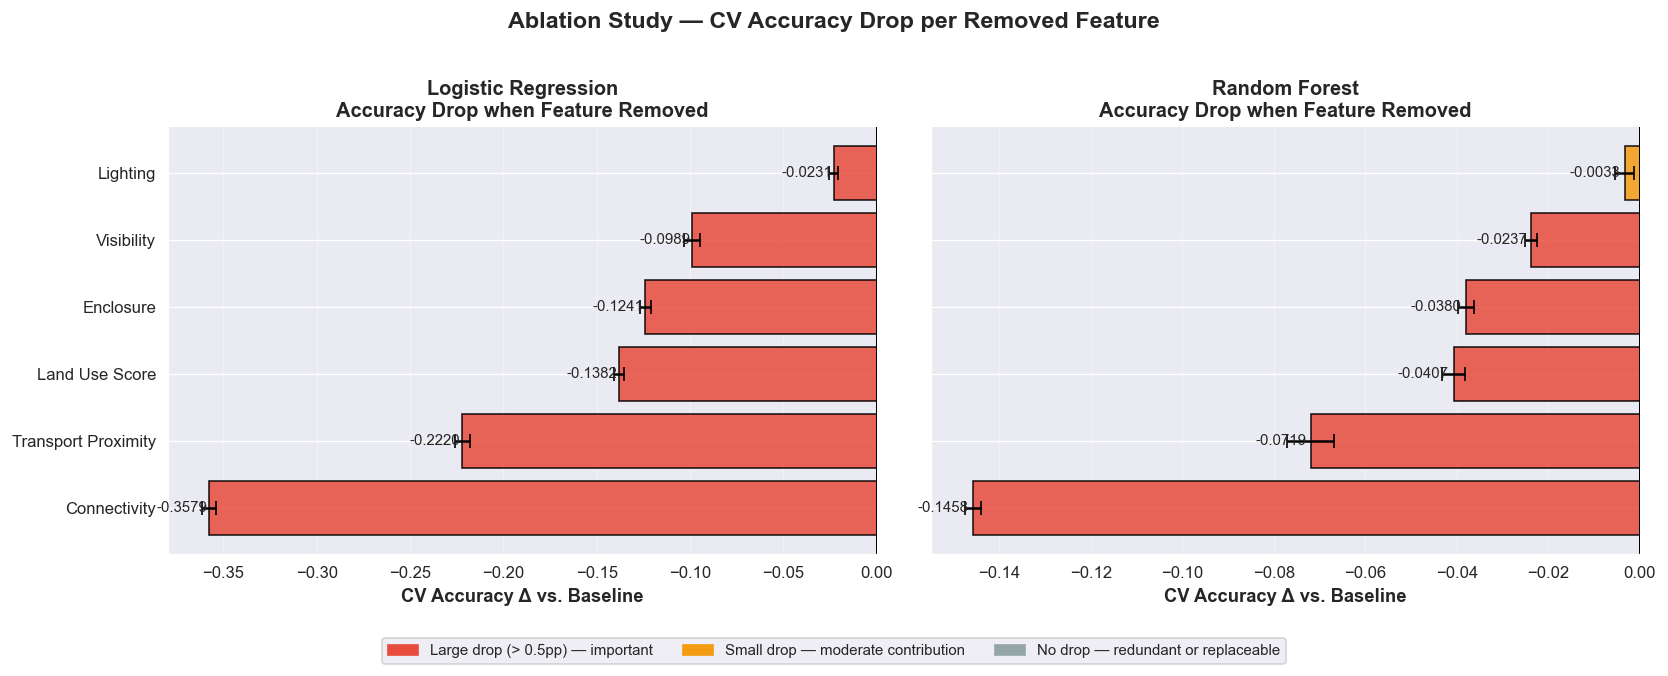

✓ Saved plots/ablation_accuracy_drop.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, model, delta_col, cv_col, cv_std_col, title in zip(
    axes,
    ['LR', 'RF'],
    ['lr_cv_delta', 'rf_cv_delta'],
    ['lr_cv', 'rf_cv'],
    ['lr_cv_std', 'rf_cv_std'],
    ['Logistic Regression', 'Random Forest']
):
    plot_df = ablation_df.sort_values(delta_col)
    colors  = ['#e74c3c' if v < -0.005 else '#f39c12' if v < 0 else '#95a5a6'
               for v in plot_df[delta_col]]

    bars = ax.barh(
        plot_df['dropped_feature'],
        plot_df[delta_col],
        xerr=plot_df[cv_std_col],
        color=colors,
        edgecolor='black',
        alpha=0.85,
        capsize=4
    )
    ax.axvline(0, color='black', linewidth=1.2)
    ax.set_xlabel('CV Accuracy Δ vs. Baseline', fontsize=11, fontweight='bold')
    ax.set_title(f'{title}\nAccuracy Drop when Feature Removed', fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

    # Annotate bars with delta values
    for bar, val in zip(bars, plot_df[delta_col]):
        offset = -0.001 if val < 0 else 0.001
        ha     = 'right' if val < 0 else 'left'
        ax.text(
            val + offset, bar.get_y() + bar.get_height() / 2,
            f'{val:+.4f}', va='center', ha=ha, fontsize=9
        )

legend_elements = [
    mpatches.Patch(color='#e74c3c', label='Large drop (> 0.5pp) — important'),
    mpatches.Patch(color='#f39c12', label='Small drop — moderate contribution'),
    mpatches.Patch(color='#95a5a6', label='No drop — redundant or replaceable'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.08),
           frameon=True, fontsize=9)

plt.suptitle('Ablation Study — CV Accuracy Drop per Removed Feature',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

os.makedirs('plots', exist_ok=True)
plt.savefig('plots/ablation_accuracy_drop.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved plots/ablation_accuracy_drop.png')

## Step 6: Ranked Feature Importance (by Accuracy Drop)

Here we rank features by the average accuracy drop across both models — giving a single, combined importance score.

In [9]:
ablation_df['mean_cv_delta'] = (ablation_df['lr_cv_delta'] + ablation_df['rf_cv_delta']) / 2
ranked = ablation_df[['dropped_feature', 'lr_cv_delta', 'rf_cv_delta', 'mean_cv_delta']].sort_values('mean_cv_delta')

print('Feature ranking by average CV accuracy drop (most to least important):')
print(f'{"Rank":<5} {"Feature":<25} {"LR Δ":>9} {"RF Δ":>9} {"Avg Δ":>9}')
print('-' * 60)
for rank, (_, row) in enumerate(ranked.iterrows(), 1):
    print(f"{rank:<5} {row['dropped_feature']:<25} {row['lr_cv_delta']:>+9.4f} {row['rf_cv_delta']:>+9.4f} {row['mean_cv_delta']:>+9.4f}")

print(f"\nMost important feature  : {ranked.iloc[0]['dropped_feature']}  (avg Δ = {ranked.iloc[0]['mean_cv_delta']:+.4f})")
print(f"Least important feature : {ranked.iloc[-1]['dropped_feature']}  (avg Δ = {ranked.iloc[-1]['mean_cv_delta']:+.4f})")

Feature ranking by average CV accuracy drop (most to least important):
Rank  Feature                        LR Δ      RF Δ     Avg Δ
------------------------------------------------------------
1     Connectivity                -0.3579   -0.1458   -0.2519
2     Transport Proximity         -0.2220   -0.0719   -0.1470
3     Land Use Score              -0.1382   -0.0407   -0.0895
4     Enclosure                   -0.1241   -0.0380   -0.0811
5     Visibility                  -0.0989   -0.0237   -0.0613
6     Lighting                    -0.0231   -0.0033   -0.0132

Most important feature  : Connectivity  (avg Δ = -0.2519)
Least important feature : Lighting  (avg Δ = -0.0132)


## Step 7: Combined Summary Chart

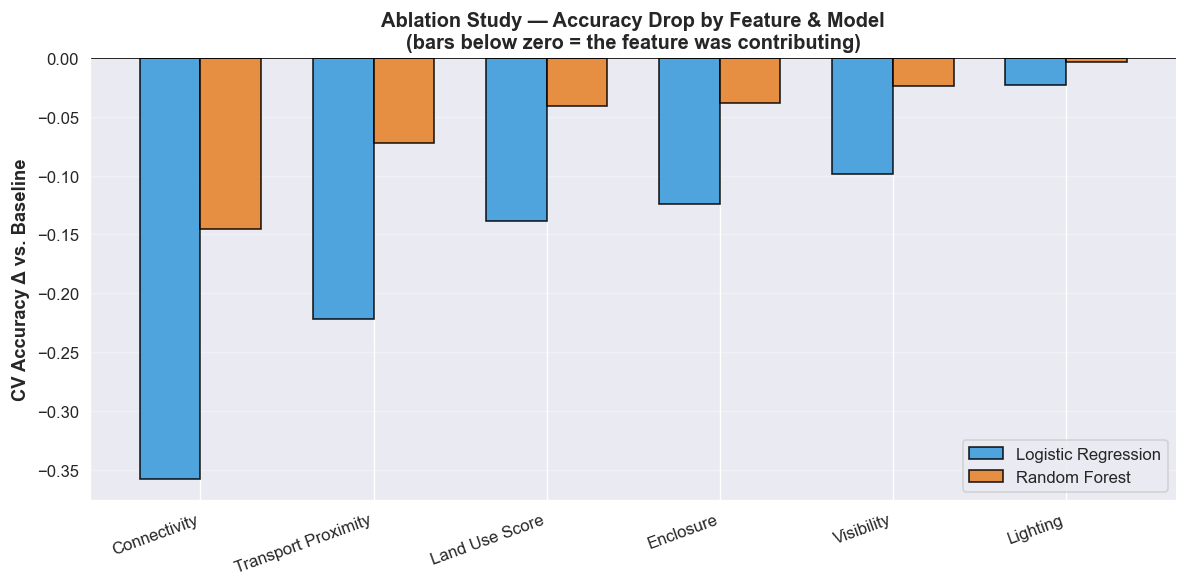

✓ Saved plots/ablation_combined.png


In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

x     = np.arange(len(ranked))
width = 0.35

bars_lr = ax.bar(x - width/2, ranked['lr_cv_delta'], width,
                 label='Logistic Regression', color='#3498db', edgecolor='black', alpha=0.85)
bars_rf = ax.bar(x + width/2, ranked['rf_cv_delta'], width,
                 label='Random Forest',       color='#e67e22', edgecolor='black', alpha=0.85)

ax.axhline(0, color='black', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(ranked['dropped_feature'], rotation=20, ha='right', fontsize=10)
ax.set_ylabel('CV Accuracy Δ vs. Baseline', fontsize=11, fontweight='bold')
ax.set_title('Ablation Study — Accuracy Drop by Feature & Model\n(bars below zero = the feature was contributing)',
             fontsize=12, fontweight='bold')
ax.legend(frameon=True, fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('plots/ablation_combined.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved plots/ablation_combined.png')

## Summary

| Step | Details |
|------|---------|
| Baseline | All 6 features, same pipeline as `05_ClassificationML.ipynb` |
| Ablation | Leave-one-out: retrain with each feature removed |
| Metric | 5-fold cross-validation accuracy (CV) and held-out test accuracy |
| Models | Logistic Regression + Random Forest |
| Output | Accuracy delta table + ranked feature importance by drop |

**Interpretation guide:**
- A feature with a large negative Δ (e.g. −0.05) is critical — removing it significantly degrades the model's ability to reproduce the K-Means risk clustering.
- A feature near zero Δ may be correlated with others or contribute less independently.
- If a feature shows a *positive* Δ, it may be introducing noise relative to the others; worth investigating.

Cross-reference with SHAP values from `07_SHAP.ipynb` for a complementary perspective: SHAP measures how the trained model *uses* each feature, while this ablation measures what happens when you *remove* it entirely from training.